In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import copy
from collections import defaultdict
import torch
from torch import nn, optim

import sys
# sys.path.append("/home/matthias/Documents/EmbeddedAI/deep-microcompression/")
sys.path.append("../../")

from development import (
    Sequential,
    EarlyStopper,
    QuantizationScheme,
    get_nas_compression_data,
    brute_force_search_compression_config, 
    evolutionary_search_compression_config,
    get_size_of_compression
)
import matplotlib.pyplot as plt



/home/matthias/Documents/EmbeddedAI/deep-microcompression/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import development.experiments.resnet as resnet
import development.experiments.cifar100 as cifar100

In [4]:

# import torch
# from torch import nn, optim
# from torch.utils import data
# from torchvision import datasets, transforms

# from development import (
#     Sequential,
#     Conv2d,
#     BatchNorm2d,
#     ReLU,
#     MaxPool2d,
#     Flatten,
#     Linear,
#     ConstantPad2d,
# )

# FILE_DIR = os.path.dirname(os.path.abspath(__name__))
# INPUT_SHAPE = (1, 28, 28)
# DATASET_DIR = "../../Datasets"
# LENET5_FILE = f"{FILE_DIR}/development/vertexai/lenet5_state_dict.pth"

# trained_file_name = LENET5_FILE



# def get_data_loaders():
#     print("Loading MNIST dataset...")
#     train_transform = transforms.Compose([
#         transforms.RandomRotation(15),
#         transforms.RandomAffine(0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
#         transforms.ToTensor(),
#         transforms.Normalize((0.1307,), (0.3081,))
#     ])
    
#     # Test/Inference should NOT have random augments, only normalization
#     test_transform = transforms.Compose([
#         transforms.ToTensor(),
#         transforms.Normalize((0.1307,), (0.3081,))
#     ])
    
#     mnist_train_dataset = datasets.MNIST(DATASET_DIR, train=True, download=True, transform=train_transform)
#     mnist_test_dataset = datasets.MNIST(DATASET_DIR, train=False, download=True, transform=test_transform)
    
#     # Increase batch size for smoother gradients if your hardware allows
#     mnist_train_loader = data.DataLoader(mnist_train_dataset, batch_size=64, shuffle=True)
#     mnist_test_loader = data.DataLoader(mnist_test_dataset, batch_size=64, shuffle=False)
    
#     return mnist_train_loader, mnist_test_loader



# def get_metric():
#     def metric(y_pred, y_true):
#         return (y_pred.argmax(dim=1) == y_true).to(torch.float).mean().item() * 100
#     return metric

# def get_model():
#     return Sequential(
#         ConstantPad2d(padding=[2]*4, value=0),
#         Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1, bias=True),
#         BatchNorm2d(num_features=6),
#         ReLU(),
#         MaxPool2d(kernel_size=2, stride=2, padding=0),
#         Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1, padding=0, bias=True),
#         BatchNorm2d(num_features=16),
#         ReLU(),
#         MaxPool2d(kernel_size=2, stride=2, padding=0),
#         Flatten(),
#         Linear(in_features=16*5*5, out_features=84, bias=True),
#         ReLU(),
#         Linear(in_features=84, out_features=10, bias=True)
#     )


In [5]:

KB = 1024
ram = 2 * KB
flash = 32 * KB 
VERTEXAI_ENV = "vertexai"
GCS_BUCKET = "deep-microcompression"

experiment_args_file = "experiment_args.pth"
baseline_model_file = "baseline_model.pth"
best_configuration_smallest_metric_file = "best_configuration_smallest_metric_file.pth"
best_configuration_smallest_for_board_file = "best_configuration_smallest_for_board_file.pth"
nas_param_file = "nas_parameters.pth"


In [6]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

/home/matthias/Documents/EmbeddedAI/deep-microcompression/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


'cpu'

In [7]:
root_dir = "/home/matthias/Documents/EmbeddedAI/deep-microcompression"

Loading CIFAR100 dataset...

--- STAGE 1: Loading Pretrained Baseline ---


/home/matthias/Documents/EmbeddedAI/deep-microcompression/development/experiments/../../development/layers/branch.py:46: UserWarning: sublayer 1 of type <class 'development.layers.block.Block'> and sublayer2 None have only one of themas a compression parameter modifying layer (it recomputes its parameters) like Linear or Conv but the other uses the parameters from the previous layers, this will result in the modifying layer having it parameters tied to that of the non modifying layer.
  warnings.warn((f"sublayer 1 of type {type(sublayer1)} and sublayer2 {sublayer2} have only one of them"


  All 344 tensors transferred successfully.
  Param count check passed: 861,620 params in both models.


In [9]:
baseline_model_state_dict = torch.load(os.path.join("/home/matthias/Downloads", "experiments_resnet_cifar100_baseline_model.pth"), map_location=DEVICE, weights_only=False)["model"]

In [10]:
baseline_model.load_state_dict(baseline_model_state_dict, strict=True)

<All keys matched successfully>

In [11]:
original_metric = baseline_model.evaluate(test_loader, metrics={"acc": metric}, device=DEVICE)["acc"]
original_metric

72.61

In [12]:
estimator_history = torch.load(os.path.join("/home/matthias/Downloads", "experiments_resnet_cifar100_estimator_training_history_file.pth"), weights_only=False)

fig, axes = plt.subplots(1, 2)

axes[0].plot(estimator_history["validation_abs"], label="val")
axes[0].plot(estimator_history["train_abs"], label="train")

axes[0].legend()



axes[1].plot(estimator_history["validation_mse"], label="val")
axes[1].plot(estimator_history["train_mse"], label="train")

axes[1].legend()

FileNotFoundError: [Errno 2] No such file or directory: '/home/matthias/Downloads/experiments_resnet_cifar100_estimator_training_history_file.pth'

In [13]:
nas_parameters_dict1 = torch.load(os.path.join("/home/matthias/Downloads", "experiments_resnet_cifar100_nas_parameters.pth-(50)-(1778691612)-(train-True)"), weights_only=False)
# nas_parameters_dict2 = torch.load(os.path.join("/home/matthias/Downloads", "experiments_lenet5_mnist_nas_parameters.pth-(500)-(1769536339)-(train-True)"), weights_only=False)

In [14]:
def get_nas_parameters(nas_file):
    nas_parameters_dict = torch.load(os.path.join("/home/matthias/Downloads", nas_file), weights_only=False)
    nas_parameter = nas_parameters_dict["nas_parameters"]

    return nas_parameter

nas_file_list = ["experiments_resnet_cifar100_nas_parameters.pth-(50)-(1778691612)-(train-True)"]
                #   "experiments_resnet_cifar100_nas_parameters.pth-(500)-(1778691612)-(train-True)"]

combined_nas_parameter_dict = defaultdict(list)
for nas_file in nas_file_list:
    for key, values in get_nas_parameters(nas_file).items():
        combined_nas_parameter_dict[key].extend(values)

nas_len = len(next(iter(combined_nas_parameter_dict.values())))
for k, v in combined_nas_parameter_dict.items():
    print(k, len(v))
# metric_values = combined_nas_parameter_dict.pop("metric")
nas_len

prune_channel.sparsity.conv2d_0 50
prune_channel.sparsity.branch_0 50
prune_channel.sparsity.branch_1 50
prune_channel.sparsity.branch_2 50
prune_channel.sparsity.branch_3 50
prune_channel.sparsity.branch_4 50
prune_channel.sparsity.branch_5 50
prune_channel.sparsity.branch_6 50
prune_channel.sparsity.branch_7 50
prune_channel.sparsity.branch_8 50
prune_channel.sparsity.branch_9 50
prune_channel.sparsity.branch_10 50
prune_channel.sparsity.branch_11 50
prune_channel.sparsity.branch_12 50
prune_channel.sparsity.branch_13 50
prune_channel.sparsity.branch_14 50
prune_channel.sparsity.branch_15 50
prune_channel.sparsity.branch_16 50
prune_channel.sparsity.branch_17 50
prune_channel.sparsity.branch_18 50
prune_channel.sparsity.branch_19 50
prune_channel.sparsity.branch_20 50
prune_channel.sparsity.branch_21 50
prune_channel.sparsity.branch_22 50
prune_channel.sparsity.branch_23 50
prune_channel.sparsity.branch_24 50
prune_channel.sparsity.branch_25 50
prune_channel.sparsity.branch_26 50
pru

50

In [20]:

nas_parameters = nas_parameters_dict1["nas_parameters"].copy()

nas_len = len(next(iter(nas_parameters.values())))
for k, v in nas_parameters.items():
    print(k, len(v))
metric_values = nas_parameters.pop("metric")
nas_len


prune_channel.sparsity.conv2d_0 50
prune_channel.sparsity.branch_0 50
prune_channel.sparsity.branch_1 50
prune_channel.sparsity.branch_2 50
prune_channel.sparsity.branch_3 50
prune_channel.sparsity.branch_4 50
prune_channel.sparsity.branch_5 50
prune_channel.sparsity.branch_6 50
prune_channel.sparsity.branch_7 50
prune_channel.sparsity.branch_8 50
prune_channel.sparsity.branch_9 50
prune_channel.sparsity.branch_10 50
prune_channel.sparsity.branch_11 50
prune_channel.sparsity.branch_12 50
prune_channel.sparsity.branch_13 50
prune_channel.sparsity.branch_14 50
prune_channel.sparsity.branch_15 50
prune_channel.sparsity.branch_16 50
prune_channel.sparsity.branch_17 50
prune_channel.sparsity.branch_18 50
prune_channel.sparsity.branch_19 50
prune_channel.sparsity.branch_20 50
prune_channel.sparsity.branch_21 50
prune_channel.sparsity.branch_22 50
prune_channel.sparsity.branch_23 50
prune_channel.sparsity.branch_24 50
prune_channel.sparsity.branch_25 50
prune_channel.sparsity.branch_26 50
pru

50

In [21]:
estimator = Estimator(
    combined_nas_parameter_dict, baseline_model.get_compression_possible_hyperparameters(),
    device=DEVICE, hidden_dim=[128, 128], dropout=.6, early_stopper_patience=100
)
estimator_history = estimator.fit(epochs=1000)


estimator_history.keys()


NameError: name 'Estimator' is not defined

In [17]:
validation_loss = [val.item() for val in estimator_history["validation_loss"]]

NameError: name 'estimator_history' is not defined

/tmp/ipykernel_174955/1444916592.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


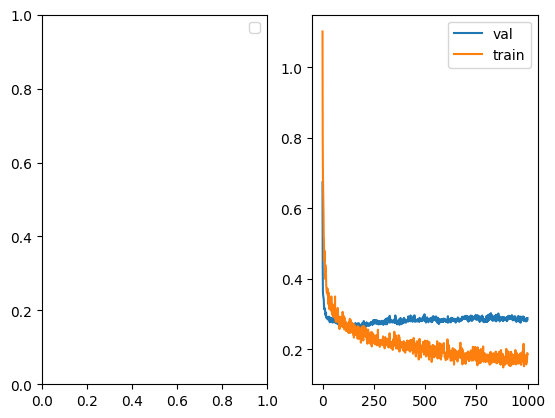

In [ ]:
estimator_history.keys()
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2)

# axes[0].plot(estimator_history["validation_abs"], label="val")
# axes[0].plot(estimator_history["train_abs"], label="train")

axes[0].legend()



axes[1].plot(validation_loss, label="val")
axes[1].plot(estimator_history["train_loss"], label="train")

axes[1].legend()

/tmp/ipykernel_174955/353280416.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

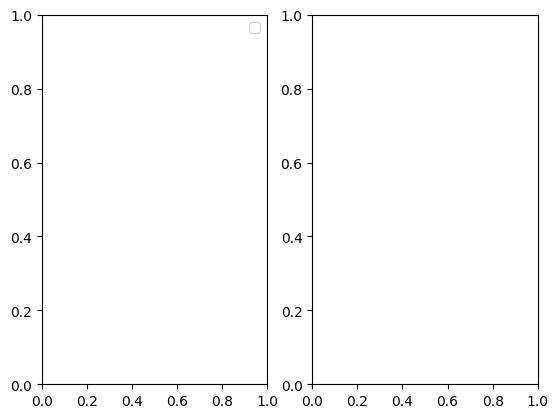

In [ ]:
estimator_history.keys()
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2)

# axes[0].plot(estimator_history["validation_abs"], label="val")
# axes[0].plot(estimator_history["train_abs"], label="train")

axes[0].legend()



axes[1].plot(estimator_history["validation_loss"], label="val")
axes[1].plot(estimator_history["train_loss"], label="train")

axes[1].legend()

In [ ]:
size_list = list()
metric_list = list()
estimated_metric_list = list()
abs_error_list = list()

nas_parameters = copy.deepcopy(combined_nas_parameter_dict)
metric_values = nas_parameters.pop("metric")
for i in range(nas_len):
    config = {k: v[i] for k, v in nas_parameters.items()}
    estimated_metric = estimator.predict(config).item()

    config = baseline_model.decode_compression_dict_hyperparameter(config)

    size = baseline_model.init_compress(
        config, INPUT_SHAPE, calibration_data, DEVICE
    ).get_size_in_bytes()
    real_metric = metric_values[i]

    estimated_metric_list.append(estimated_metric)
    size_list.append(size)
    metric_list.append(real_metric)
    abs_error_list.append(abs(real_metric - estimated_metric))



In [ ]:
metric_values.index(max(metric_values))

308

In [ ]:
for key in combined_nas_parameter_dict:
    print(combined_nas_parameter_dict[key][308])

3
2
25
l2
QuantizationScheme.STATIC
4
4
QuantizationGranularity.PER_CHANNEL
8
QuantizationGranularity.PER_CHANNEL
8
QuantizationGranularity.PER_CHANNEL
8
QuantizationGranularity.PER_TENSOR
97.82


In [ ]:
abs_error_list

[19.797543029785157,
 6.1260283660888675,
 3.2478289794921835,
 10.340804748535156,
 7.998523483276367,
 7.027705917358398,
 24.19944351196289,
 9.192483978271483,
 1.782851257324225,
 5.759410705566406,
 13.47730094909668,
 14.052449340820317,
 5.185017700195317,
 13.289982681274415,
 14.684267959594727,
 8.402314834594726,
 0.7131066894531273,
 10.31483268737793,
 1.3116918945312506,
 7.061829986572267,
 13.119237060546874,
 10.770696868896486,
 2.7926971435546903,
 5.065871582031249,
 8.370693893432618,
 34.643156890869136,
 1.4189495849609344,
 1.3549206542968761,
 8.925221633911132,
 7.050618362426757,
 4.598075866699219,
 7.9075969696044925,
 7.243416137695306,
 14.313552932739258,
 8.60730308532715,
 5.127502822875977,
 3.9167401123046943,
 5.205373535156255,
 17.16434356689453,
 26.868604736328123,
 2.1579611206054636,
 4.403149719238279,
 23.01311019897461,
 3.0899707031250045,
 8.445022583007812,
 11.132639312744141,
 3.775577697753903,
 8.68832176208496,
 28.82790008544922,


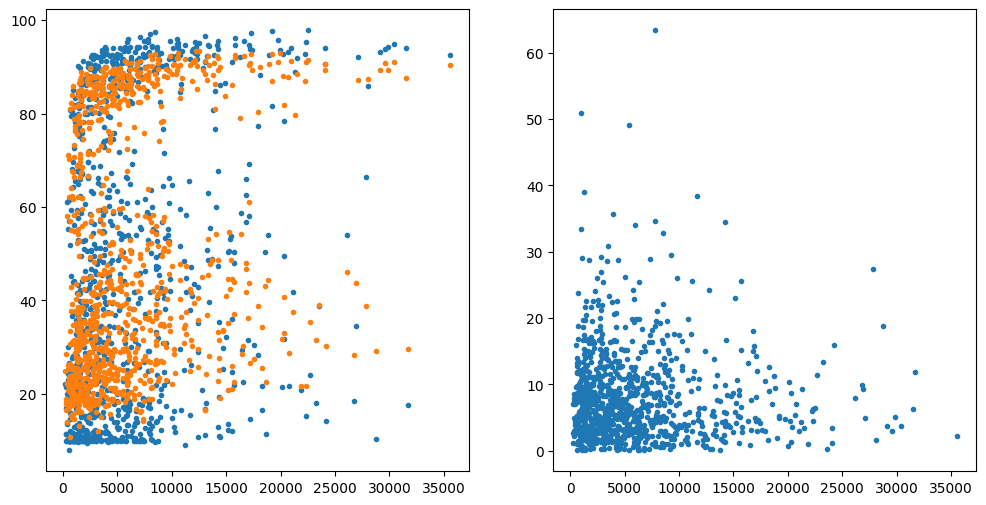

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].scatter(size_list, metric_list, marker=".")
axes[0].scatter(size_list, estimated_metric_list, marker=".")

axes[1].scatter(size_list, abs_error_list, marker=".")


In [ ]:

def get_search_for_smallest_best_condition(baseline_model, input_shape):

    original_workspace_size = baseline_model.get_workspace_size(input_shape=input_shape)
    original_model_size = baseline_model.get_size_in_bytes()

    def condition(metric, size, ram, config):
        # filter out not static quantization
        if config["quantize"]["scheme"] != QuantizationScheme.STATIC:
            return False
        # filter out if activation cannot size in ram
        if ram / original_workspace_size > .25:
            return False
        # filter out if model size cannot size in flash
        if size / original_model_size > .25:
            return False
        # print(metric)
        # if original_metric - metric > 5:
        #     return False
        # print(metric, size, ram, config)
        return True
    
    return condition



def get_search_for_smallest_best_condition_specific_to_bard(baseline_model, input_shape):

    original_workspace_size = baseline_model.get_workspace_size(input_shape=input_shape)
    original_model_size = baseline_model.get_size_in_bytes()

    def condition(metric, size, ram, config):
        # filter out not static quantization
        if config["quantize"]["scheme"] != QuantizationScheme.STATIC:
            return False
        # filter out if activation cannot size in ram
        if ram > 1600:
            return False
        # filter out if model size cannot size in flash
        if size > 20*1024:
            return False
        # print(metric)
        # if original_metric - metric > 5:
        #     return False
        # print(metric, size, ram, config)
        return True
    
    return condition

def get_model_filter_for_nas(baseline_model, input_shape):

    original_workspace_size = baseline_model.get_workspace_size(input_shape=input_shape)
    original_model_size = baseline_model.get_size_in_bytes()

    def model_filter_for_nas(compressed_model:Sequential, compression_config):
        # filter out not static quantization
        if compression_config["quantize"]["scheme"] != QuantizationScheme.STATIC:
            return False
        # filter out if activation cannot size in ram
        if compressed_model.get_workspace_size(input_shape=input_shape) / original_workspace_size > .25:
            return False
        # filter out if model size cannot size in flash
        if compressed_model.get_size_in_bytes() / original_model_size > .25:
            return False
        return True
    
    return model_filter_for_nas


In [ ]:
def train_compressed_model(
        baseline_model, 
        epoch, 
        train_loader, 
        test_loader, 
        compression_config, 
        metric, 
        input_shape, 
        lr,
        lr_scheduler_patience,
        lr_factor,
        device, 
        two_step=True
    ):
    
    print(f"Applying compression configuration: {compression_config}")

    calibration_data = next(iter(train_loader))[0].to(device=device)
    
    if two_step:
        prune_epoch = int(epoch/2)
        epoch = epoch - prune_epoch

        prune_config = copy.deepcopy(compression_config)
        del prune_config["quantize"]
        pruned_model = baseline_model.init_compress(prune_config, input_shape, calibration_data=calibration_data, device=device)

        # Retrain (fine-tune) the compressed model
        print(f"Retraining compressed model in a single step approach ({epoch} epochs)...")
        criterion_fun = nn.CrossEntropyLoss()
        optimizer_fun = optim.SGD(pruned_model.parameters(), lr=lr, weight_decay=5e-4, momentum=.9)
        lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer_fun, mode="min", patience=lr_scheduler_patience, factor=lr_factor)

        pruned_model.fit(
            train_loader, prune_epoch, 
            criterion_fun, optimizer_fun, lr_scheduler,
            validation_dataloader=test_loader, 
            metrics={"metric": metric},
            device=device
        )

        baseline_model = pruned_model

    # Re-initialize model architecture with pruning
    compressed_model = baseline_model.init_compress(compression_config, input_shape, calibration_data=calibration_data, device=device)
    
    # Retrain (fine-tune) the compressed model
    print(f"Retraining compressed model in a single step approach ({epoch} epochs)...")
    criterion_fun = nn.CrossEntropyLoss()
    optimizer_fun = optim.SGD(compressed_model.parameters(), lr=lr, weight_decay=5e-4, momentum=.9)
    lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer_fun, mode="min", patience=lr_scheduler_patience, factor=lr_factor)

    compressed_model.fit(
        train_loader, epoch, 
        criterion_fun, optimizer_fun, lr_scheduler,
        validation_dataloader=test_loader, 
        metrics={"metric": metric},
        device=device
    )

    return compressed_model


In [ ]:

importance = .7
calibration_data = next(iter(train_loader))[0].to(device=DEVICE)

original_model_size = baseline_model.get_size_in_bytes()
# Note: condition depends on estimator scale. Assuming estimator predicts 0-100 accuracy.
best_configuration, best_result_info = evolutionary_search_compression_config(
    baseline_model,
    estimator,
    INPUT_SHAPE,
    calibration_data,
    condition=get_search_for_smallest_best_condition(baseline_model, INPUT_SHAPE), 
    objective= lambda metric, size, ram, config: size/original_model_size *100 - importance * metric, 
    filter=get_model_filter_for_nas(baseline_model, INPUT_SHAPE),
    maximize=False, # Minimize Size
    verbose=True,
    population_size=100,
    generations=100
)


best_configuration = baseline_model.decode_compression_dict_hyperparameter(best_configuration)
best_configuration

  0%|          | 0/100 [00:00<?, ?it/s]

Gen 0: ✔ New best! Obj=-14.0432 Metric=21.9546 Size=1969.0000 Ram=452.0000
Gen 0: ✔ New best! Obj=-45.3611 Metric=65.8572 Size=1098.0000 Ram=904.0000
Gen 0: ✔ New best! Obj=-59.5400 Metric=87.9325 Size=2991.0000 Ram=1808.0000
Gen 0: ✔ New best! Obj=-61.9225 Metric=90.3122 Size=1926.0000 Ram=1808.0000


  1%|          | 1/100 [00:03<05:11,  3.15s/it]

Gen 0/100 Complete. Avg Score: -38.3546
Gen 1: ✔ New best! Obj=-62.2433 Metric=91.5013 Size=2686.0000 Ram=904.0000
Gen 1: ✔ New best! Obj=-63.4311 Metric=96.0139 Size=5615.0000 Ram=1808.0000


  2%|▏         | 2/100 [00:06<05:08,  3.15s/it]

...

 99%|█████████▉| 99/100 [06:06<00:03,  3.50s/it]

Gen 98/100 Complete. Avg Score: -65.9334


100%|██████████| 100/100 [06:09<00:00,  3.70s/it]

Gen 99/100 Complete. Avg Score: -66.1950


{'prune_channel': {'sparsity': {'conv2d_0': 0, 'conv2d_1': 15, 'linear_0': 0},
  'metric': 'l2'},
 'quantize': {'scheme': <QuantizationScheme.STATIC: 3>,
  'activation_bitwidth': 8,
  'parameter_bitwidth': {'conv2d_0': 8,
   'conv2d_1': 8,
   'linear_0': 4,
   'linear_1': 8},
  'granularity': {'conv2d_0': <QuantizationGranularity.PER_TENSOR: 1>,
   'conv2d_1': <QuantizationGranularity.PER_TENSOR: 1>,
   'linear_0': <QuantizationGranularity.PER_TENSOR: 1>,
   'linear_1': <QuantizationGranularity.PER_CHANNEL: 2>}}}

In [ ]:

compressed_model = train_compressed_model(
    baseline_model, 
    10, 
    train_loader, 
    test_loader, 
    best_configuration, 
    metric, 
    INPUT_SHAPE, 
    1e-3,
    1,
    .33,
    DEVICE
)

Applying compression configuration: {'prune_channel': {'sparsity': {'conv2d_0': 0, 'conv2d_1': 15, 'linear_0': 16}, 'metric': 'l2'}, 'quantize': {'scheme': <QuantizationScheme.STATIC: 3>, 'activation_bitwidth': 4, 'parameter_bitwidth': {'conv2d_0': 4, 'conv2d_1': 4, 'linear_0': 8, 'linear_1': 4}, 'granularity': {'conv2d_0': <QuantizationGranularity.PER_CHANNEL: 2>, 'conv2d_1': <QuantizationGranularity.PER_TENSOR: 1>, 'linear_0': <QuantizationGranularity.PER_CHANNEL: 2>, 'linear_1': <QuantizationGranularity.PER_TENSOR: 1>}}}
Retraining compressed model in a single step approach (5 epochs)...


DMC Training (Epochs 1-5):  20%|██        | 1/5 [00:43<02:53, 43.41s/it]

epoch    0 | train loss 1.7481 | validation loss 0.7972 | train metric 38.7133 | validation metric 77.0900


DMC Training (Epochs 1-5):  40%|████      | 2/5 [01:36<02:27, 49.27s/it]

epoch    1 | train loss 1.1412 | validation loss 0.5811 | train metric 61.7517 | validation metric 82.5500


...

epoch    3 | train loss 0.9245 | validation loss 0.4738 | train metric 69.7833 | validation metric 86.4500


DMC Training (Epochs 1-5): 100%|██████████| 5/5 [04:25<00:00, 53.08s/it]


epoch    4 | train loss 0.8543 | validation loss 0.4374 | train metric 72.2183 | validation metric 87.7900
Retraining compressed model in a single step approach (5 epochs)...


DMC Training (Epochs 1-5):  20%|██        | 1/5 [01:14<04:58, 74.57s/it]

epoch    0 | train loss 1.0781 | validation loss 0.6410 | train metric 63.3967 | validation metric 79.6900


In [ ]:
print(f"Searching for smallest config to fit in board with")
best_configuration, best_result_info = evolutionary_search_compression_config(
    baseline_model,
    estimator,
    INPUT_SHAPE,
    calibration_data,
    condition=get_search_for_smallest_best_condition_specific_to_bard(baseline_model, INPUT_SHAPE), 
    objective= lambda metric, size, ram, config: metric, 
    filter=get_model_filter_for_nas(baseline_model, INPUT_SHAPE),
    maximize=True, # Minimize Size
    verbose=True,
    population_size=50,
    generations=50
)

best_configuration = baseline_model.decode_compression_dict_hyperparameter(best_configuration)
print(f"best configuration: {best_configuration}\nbest_result_info: {best_result_info}")


Searching for smallest config to fit in board with


  0%|          | 0/50 [00:00<?, ?it/s]

Gen 0: ✔ New best! Obj=67.2491 Metric=67.2491 Size=1207.0000 Ram=1000.0000
Gen 0: ✔ New best! Obj=85.9624 Metric=85.9624 Size=2424.0000 Ram=1500.0000
Gen 0: ✔ New best! Obj=94.9141 Metric=94.9141 Size=14481.0000 Ram=1200.0000


  2%|▏         | 1/50 [00:01<01:34,  1.93s/it]

Gen 0/50 Complete. Avg Score: 54.7686
Gen 1: ✔ New best! Obj=96.8418 Metric=96.8418 Size=14239.0000 Ram=1200.0000


...

Gen 47/50 Complete. Avg Score: 103.6456


 98%|█████████▊| 49/50 [01:03<00:01,  1.44s/it]

Gen 48/50 Complete. Avg Score: 105.1847


100%|██████████| 50/50 [01:04<00:00,  1.29s/it]

Gen 49/50 Complete. Avg Score: 105.2605
best configuration: {'prune_channel': {'sparsity': {'conv2d_0': 0, 'conv2d_1': 2, 'linear_0': 31}, 'metric': 'l2'}, 'quantize': {'scheme': <QuantizationScheme.STATIC: 3>, 'activation_bitwidth': 4, 'parameter_bitwidth': {'conv2d_0': 8, 'conv2d_1': 8, 'linear_0': 8, 'linear_1': 4}, 'granularity': {'conv2d_0': <QuantizationGranularity.PER_CHANNEL: 2>, 'conv2d_1': <QuantizationGranularity.PER_CHANNEL: 2>, 'linear_0': <QuantizationGranularity.PER_TENSOR: 1>, 'linear_1': <QuantizationGranularity.PER_CHANNEL: 2>}}}
best_result_info: {'metric': 105.66118621826172, 'size': 19782, 'ram': 1400}


In [ ]:

compressed_model = train_compressed_model(
    baseline_model, 
    10, 
    train_loader, 
    test_loader, 
    best_configuration, 
    metric, 
    INPUT_SHAPE, 
    1e-3,
    1,
    .33,
    DEVICE
)

Applying compression configuration: {'prune_channel': {'sparsity': {'conv2d_0': 0, 'conv2d_1': 2, 'linear_0': 31}, 'metric': 'l2'}, 'quantize': {'scheme': <QuantizationScheme.STATIC: 3>, 'activation_bitwidth': 4, 'parameter_bitwidth': {'conv2d_0': 8, 'conv2d_1': 8, 'linear_0': 8, 'linear_1': 4}, 'granularity': {'conv2d_0': <QuantizationGranularity.PER_CHANNEL: 2>, 'conv2d_1': <QuantizationGranularity.PER_CHANNEL: 2>, 'linear_0': <QuantizationGranularity.PER_TENSOR: 1>, 'linear_1': <QuantizationGranularity.PER_CHANNEL: 2>}}}
Retraining compressed model in a single step approach (5 epochs)...


DMC Training (Epochs 1-5):   0%|          | 0/5 [00:00<?, ?it/s]

DMC Training (Epochs 1-5):  20%|██        | 1/5 [00:26<01:45, 26.50s/it]

epoch    0 | train loss 0.7070 | validation loss 0.2086 | train metric 78.2417 | validation metric 93.5300


DMC Training (Epochs 1-5):  40%|████      | 2/5 [00:54<01:21, 27.12s/it]

...

epoch    2 | train loss 0.3568 | validation loss 0.1804 | train metric 88.3817 | validation metric 94.3400


DMC Training (Epochs 1-5):  80%|████████  | 4/5 [02:12<00:33, 33.50s/it]

epoch    3 | train loss 0.3458 | validation loss 0.1703 | train metric 88.8067 | validation metric 94.6700


DMC Training (Epochs 1-5): 100%|██████████| 5/5 [02:48<00:00, 33.75s/it]

epoch    4 | train loss 0.3448 | validation loss 0.1680 | train metric 88.7883 | validation metric 94.4400


In [ ]:
nas_param_dict = torch.load(os.path.join(root_dir, f"{nas_param_file} (train {True})"), weights_only=False)
nas_parameters = nas_param_dict["nas_parameters"]

In [ ]:
estimator = Estimator(
    nas_parameters, baseline_model.get_commpression_possible_hyperparameters(),
    device=DEVICE, hidden_dim=[128, 256, 512, 256], dropout=0.5
)
estimator_history = estimator.fit(epochs=1_000)


AttributeError: 'Sequential' object has no attribute 'get_commpression_possible_hyperparameters'

In [ ]:
nas_parameters

defaultdict(list,
            {'prune_channel.sparsity.conv2d_0': [4, 4, 3, 1, 3, 1, 4, 5, 5, 0],
             'prune_channel.sparsity.conv2d_1': [10,
              14,
              14,
              4,
              13,
              8,
              10,
              6,
              2,
              3],
             'prune_channel.sparsity.linear_0': [23,
              9,
              55,
              47,
              57,
              65,
              10,
              70,
              15,
              71],
             'prune_channel.metric': ['l2',
              'l2',
              'l2',
              'l2',
              'l2',
              'l2',
              'l2',
              'l2',
              'l2',
              'l2'],
             'quantize.scheme': [<QuantizationScheme.STATIC: 3>,
              <QuantizationScheme.STATIC: 3>,
              <QuantizationScheme.STATIC: 3>,
              <QuantizationScheme.STATIC: 3>,
              <QuantizationScheme.STATIC: 3>,
  

AttributeError: 'Sequential' object has no attribute 'get_min_workspace_arena'

In [ ]:
best_configuration

{'prune_channel': {'sparsity': {'conv2d_0': 3, 'conv2d_1': 13, 'linear_0': 63},
  'metric': 'l2'},
 'quantize': {'scheme': <QuantizationScheme.STATIC: 3>,
  'activation_bitwidth': 4,
  'parameter_bitwidth': {'conv2d_0': 8,
   'conv2d_1': 4,
   'linear_0': 8,
   'linear_1': 4},
  'granularity': {'conv2d_0': <QuantizationGranularity.PER_TENSOR: 1>,
   'conv2d_1': <QuantizationGranularity.PER_CHANNEL: 2>,
   'linear_0': <QuantizationGranularity.PER_TENSOR: 1>,
   'linear_1': <QuantizationGranularity.PER_TENSOR: 1>}}}

In [ ]:
import copy
def train_compressed_model(
        baseline_model, 
        epoch, 
        train_loader, 
        test_loader, 
        compression_config, 
        metric, 
        input_shape, 
        lr,
        lr_scheduler_patience,
        lr_factor,
        device, 
        two_step=True
    ):

    calibration_data = next(iter(train_loader))[0].to(device=device)
    
    if two_step:
        prune_epoch = int(epoch/2)
        epoch = epoch - prune_epoch

        prune_config = copy.deepcopy(compression_config)
        del prune_config["quantize"]
        pruned_model = baseline_model.init_compress(prune_config, input_shape, calibration_data=calibration_data, device=device)

        # Retrain (fine-tune) the compressed model
        criterion_fun = nn.CrossEntropyLoss()
        optimizer_fun = optim.SGD(pruned_model.parameters(), lr=lr, weight_decay=5e-4, momentum=.9)
        lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer_fun, mode="min", patience=lr_scheduler_patience, factor=lr_factor)

        pruned_model.fit(
            train_loader, prune_epoch, 
            criterion_fun, optimizer_fun, lr_scheduler,
            validation_dataloader=test_loader, 
            metrics={"metric": metric},
            device=device
        )

        baseline_model = pruned_model

    # Re-initialize model architecture with pruning
    compressed_model = baseline_model.init_compress(compression_config, input_shape, calibration_data=calibration_data, device=device)
    
    # Retrain (fine-tune) the compressed model
    criterion_fun = nn.CrossEntropyLoss()
    optimizer_fun = optim.SGD(compressed_model.parameters(), lr=lr, weight_decay=5e-4, momentum=.9)
    lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer_fun, mode="min", patience=lr_scheduler_patience, factor=lr_factor)

    compressed_model.fit(
        train_loader, epoch, 
        criterion_fun, optimizer_fun, lr_scheduler,
        validation_dataloader=test_loader, 
        metrics={"metric": metric},
        device=device
    )

    return compressed_model


In [ ]:

compressed_model = train_compressed_model(
    baseline_model, 
    15, 
    train_loader, 
    test_loader, 
    best_configuration, 
    metric, 
    INPUT_SHAPE, 
    1e-3,
    1,
    .33,
    DEVICE
)
metric_value = compressed_model.evaluate(test_loader, {"metric": metric}, device=DEVICE)

DMC Training (Epochs 1-15):   7%|▋         | 1/15 [00:38<08:56, 38.30s/it]

epoch    0 | train loss 0.6922 | validation loss 0.3558 | train metric 77.1417 | validation metric 88.0700


DMC Training (Epochs 1-15):  13%|█▎        | 2/15 [01:21<08:56, 41.27s/it]

epoch    1 | train loss 0.3406 | validation loss 0.2670 | train metric 88.7817 | validation metric 90.9400


DMC Training (Epochs 1-15):  20%|██        | 3/15 [02:00<08:01, 40.09s/it]

...

epoch   12 | train loss 0.2223 | validation loss 0.1902 | train metric 92.7650 | validation metric 93.3500


DMC Training (Epochs 1-15):  93%|█████████▎| 14/15 [10:08<00:44, 44.58s/it]

epoch   13 | train loss 0.2166 | validation loss 0.1779 | train metric 92.9433 | validation metric 93.6800


DMC Training (Epochs 1-15): 100%|██████████| 15/15 [10:44<00:00, 42.99s/it]


epoch   14 | train loss 0.2142 | validation loss 0.1923 | train metric 93.0800 | validation metric 93.6000


In [ ]:

compressed_model = train_compressed_model(
    baseline_model, 
    30, 
    train_loader, 
    test_loader, 
    best_configuration, 
    metric, 
    INPUT_SHAPE, 
    1e-3,
    1,
    .33,
    DEVICE,
    two_step = True
)
metric_value = compressed_model.evaluate(test_loader, {"metric": metric}, device=DEVICE)

DMC Training (Epochs 1-15):   7%|▋         | 1/15 [00:24<05:39, 24.26s/it]

epoch    0 | train loss 0.5614 | validation loss 0.2596 | train metric 82.7783 | validation metric 91.9400


DMC Training (Epochs 1-15):  13%|█▎        | 2/15 [00:45<04:49, 22.28s/it]

epoch    1 | train loss 0.2548 | validation loss 0.1907 | train metric 92.0967 | validation metric 94.1100


DMC Training (Epochs 1-15):  20%|██        | 3/15 [01:05<04:16, 21.38s/it]

...

epoch   12 | train loss 0.1825 | validation loss 0.1581 | train metric 94.0450 | validation metric 94.3500


DMC Training (Epochs 1-15):  93%|█████████▎| 14/15 [09:21<00:40, 40.95s/it]

epoch   13 | train loss 0.1840 | validation loss 0.1602 | train metric 93.9783 | validation metric 94.8300


DMC Training (Epochs 1-15): 100%|██████████| 15/15 [09:58<00:00, 39.89s/it]


epoch   14 | train loss 0.1846 | validation loss 0.1534 | train metric 94.0433 | validation metric 94.7300


In [ ]:

def get_model_condition_for_nas(baseline_model, input_shape):

    original_workspace_size = baseline_model.get_min_workspace_arena(input_shape=input_shape)
    original_model_size = baseline_model.get_size_in_bytes()

    def model_condition_for_nas(compressed_model:Sequential, compression_config):
        # filter out not static quantization
        if compression_config["quantize"]["scheme"] != QuantizationScheme.STATIC:
            return False
        # filter out if activation cannot size in ram
        if compressed_model.get_min_workspace_arena(input_shape=input_shape) / original_workspace_size > .25:
            return False
        # filter out if model size cannot size in flash
        if compressed_model.get_size_in_bytes() / original_model_size > .25:
            return False
        return True
    
    return model_condition_for_nas

def get_condition_for_search(baseline_model, input_shape):

    model_model_condition_for_nas = get_model_condition_for_nas(baseline_model, input_shape)

    def conditon(config):
        compressed_model = baseline_model.init_compress(config, input_shape, calibration_data=calibration_data, device=DEVICE)
        return model_model_condition_for_nas(compressed_model, config)
    return conditon


In [ ]:
calibration_data = next(iter(train_loader))[0].to(device=DEVICE)
get_size_of_compression(baseline_model, condition=get_condition_for_search(baseline_model, INPUT_SHAPE))

NameError: name 'get_condition_for_search' is not defined

In [ ]:
estimator_history.keys(), nas_parameters.keys()

(dict_keys(['validation_loss', 'validation_mse', 'validation_rmse', 'validation_abs', 'train_loss', 'train_mse', 'train_rmse', 'train_abs']),
 dict_keys(['nas_parameters', 'num_data', 'time']))

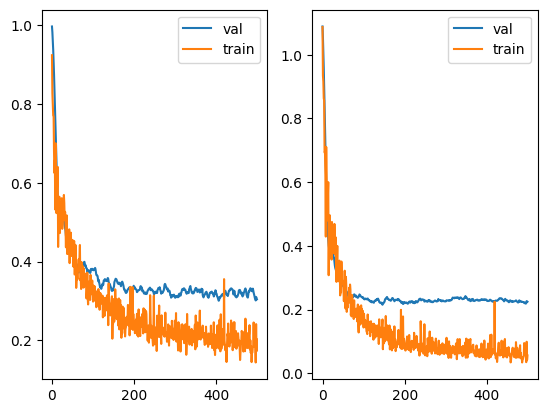

In [ ]:
nas_parameters["nas_parameters"].keys()

dict_keys(['prune_channel.sparsity.conv2d_0', 'prune_channel.sparsity.conv2d_1', 'prune_channel.sparsity.linear_0', 'prune_channel.metric', 'quantize.scheme', 'quantize.activation_bitwidth', 'quantize.parameter_bitwidth.conv2d_0', 'quantize.granularity.conv2d_0', 'quantize.parameter_bitwidth.conv2d_1', 'quantize.granularity.conv2d_1', 'quantize.parameter_bitwidth.linear_0', 'quantize.granularity.linear_0', 'quantize.parameter_bitwidth.linear_1', 'quantize.granularity.linear_1', 'metric'])

cuda:0


DMC Training (Epochs 1-500):   0%|          | 0/500 [00:00<?, ?it/s]

epoch    0 | train loss 1.0747 | validation loss 0.8279 | train mse 1.0747 | validation mse 0.8279 | train rmse 1.0367 | validation rmse 0.9099 | train abs 0.9801 | validation abs 0.8404


epoch    1 | train loss 1.0232 | validation loss 0.7978 | train mse 1.0232 | validation mse 0.7978 | train rmse 1.0108 | validation rmse 0.8932 | train abs 0.9525 | validation abs 0.8245


epoch    2 | train loss 0.9423 | validation loss 0.7682 | train mse 0.9423 | validation mse 0.7682 | train rmse 0.9707 | validation rmse 0.8765 | train abs 0.9177 | validation abs 0.8081


epoch    3 | train loss 0.9207 | validation loss 0.7413 | train mse 0.9207 | validation mse 0.7413 | train rmse 0.9585 | validation rmse 0.8610 | train abs 0.9026 | validation abs 0.7924


...

epoch  496 | train loss 0.0556 | validation loss 0.0951 | train mse 0.0556 | validation mse 0.0951 | train rmse 0.2348 | validation rmse 0.3084 | train abs 0.1853 | validation abs 0.2486


epoch  497 | train loss 0.0429 | validation loss 0.0924 | train mse 0.0429 | validation mse 0.0924 | train rmse 0.2071 | validation rmse 0.3040 | train abs 0.1637 | validation abs 0.2445


epoch  498 | train loss 0.0474 | validation loss 0.0907 | train mse 0.0474 | validation mse 0.0907 | train rmse 0.2143 | validation rmse 0.3011 | train abs 0.1708 | validation abs 0.2414


DMC Training (Epochs 1-500): 100%|██████████| 500/500 [00:08<00:00, 62.36it/s]


epoch  499 | train loss 0.0493 | validation loss 0.0922 | train mse 0.0493 | validation mse 0.0922 | train rmse 0.2221 | validation rmse 0.3037 | train abs 0.1765 | validation abs 0.2442


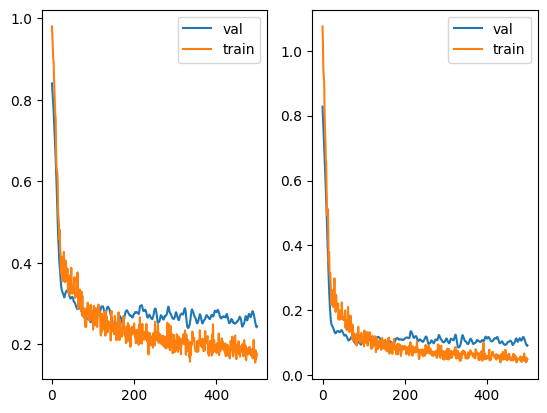

In [ ]:
def get_search_for_smallest_best_condition(baseline_model, input_shape):

    original_workspace_size = baseline_model.get_workspace_size(input_shape=input_shape)
    original_model_size = baseline_model.get_size_in_bytes()

    def condition(metric, size, ram, config):
        # filter out not static quantization
        if config["quantize"]["scheme"] != QuantizationScheme.STATIC:
            return False
        # filter out if activation cannot size in ram
        if ram / original_workspace_size > .25:
            return False
        # filter out if model size cannot size in flash
        if size / original_model_size > .25:
            return False
        if original_metric - metric > 1:
            return False
        return True
    
    return condition

def get_model_filter_for_nas(baseline_model, input_shape):

    original_workspace_size = baseline_model.get_workspace_size(input_shape=input_shape)
    original_model_size = baseline_model.get_size_in_bytes()

    def model_filter_for_nas(compressed_model:Sequential, compression_config):
        # filter out not static quantization
        if compression_config["quantize"]["scheme"] != QuantizationScheme.STATIC:
            return False
        # filter out if activation cannot size in ram
        if compressed_model.get_workspace_size(input_shape=input_shape) / original_workspace_size > .25:
            return False
        # filter out if model size cannot size in flash
        if compressed_model.get_size_in_bytes() / original_model_size > .25:
            return False
        return True
    
    return model_filter_for_nas



best_configuration, best_result_info = evolutionary_search_compression_config(
    baseline_model,
    estimator,
    INPUT_SHAPE,
    calibration_data,
    condition=get_search_for_smallest_best_condition(baseline_model, INPUT_SHAPE), 
    objective= lambda metric, size, ram, config: size, 
    filter=get_model_filter_for_nas(baseline_model, INPUT_SHAPE),
    maximize=False, # Minimize Size
    verbose=True,
    population_size=100,
    generations=100
)

  1%|          | 1/100 [00:03<06:00,  3.64s/it]

Gen 0/100 Complete. Avg Score: 0.0000


  2%|▏         | 2/100 [00:06<05:32,  3.39s/it]

Gen 1/100 Complete. Avg Score: 0.0000


  3%|▎         | 3/100 [00:10<05:19,  3.29s/it]

...

Gen 97/100 Complete. Avg Score: 7360.7841


 99%|█████████▉| 99/100 [06:12<00:05,  5.78s/it]

Gen 98/100 Complete. Avg Score: 7282.7527


100%|██████████| 100/100 [06:17<00:00,  3.77s/it]

Gen 99/100 Complete. Avg Score: 7273.0000


In [ ]:
best_configuration, best_result_info

({'prune_channel.sparsity.conv2d_0': 5,
  'prune_channel.sparsity.conv2d_1': 3,
  'prune_channel.sparsity.linear_0': 82,
  'prune_channel.metric': 'l2',
  'quantize.scheme': <QuantizationScheme.STATIC: 3>,
  'quantize.activation_bitwidth': 4,
  'quantize.parameter_bitwidth.conv2d_0': 8,
  'quantize.granularity.conv2d_0': <QuantizationGranularity.PER_TENSOR: 1>,
  'quantize.parameter_bitwidth.conv2d_1': 4,
  'quantize.granularity.conv2d_1': <QuantizationGranularity.PER_CHANNEL: 2>,
  'quantize.parameter_bitwidth.linear_0': 8,
  'quantize.granularity.linear_0': <QuantizationGranularity.PER_TENSOR: 1>,
  'quantize.parameter_bitwidth.linear_1': 4,
  'quantize.granularity.linear_1': <QuantizationGranularity.PER_TENSOR: 1>},
 {'metric': 98.04351043701172, 'size': 1168, 'ram': 1300})